# Detecção de Fraude em Cartão de Crédito

**Autor:** Luiz Felipe · **Dataset:** Credit Card Fraud Detection (ULB / Kaggle)

Este notebook desenvolve um classificador de fraude sobre uma base real de
transações de cartão de crédito. O problema tem duas características que
definem toda a abordagem:

1. **Desbalanceamento extremo** — apenas **0,17%** das transações são
   fraudulentas (492 em 284.807). Um modelo que classifica *tudo* como
   legítimo acerta 99,83% das vezes e, mesmo assim, é inútil: não pega
   uma fraude sequer. Por isso **accuracy não é uma métrica válida aqui**.
2. **Custo assimétrico** — deixar passar uma fraude (falso negativo) e
   bloquear um cliente legítimo (falso positivo) têm custos muito
   diferentes. A escolha do modelo e do ponto de corte é, no fundo, uma
   decisão de negócio, não só de estatística.

**Como o notebook trata isso:**
- Avaliação por **AUC-PR, recall e precision da classe fraude** e
  **matriz de confusão** — não por accuracy.
- **Split temporal** (treina no passado, testa no futuro) para não vazar
  informação do futuro no treino.
- **Ajuste de threshold** conforme a política de risco desejada.
- **Explicabilidade com SHAP** — requisito prático em contexto bancário,
  onde toda decisão de crédito/fraude precisa ser justificável.

### Roteiro
1. Análise exploratória
2. Pré-processamento e split temporal (sem leakage)
3. Comparação de modelos com métricas de fraude
4. Ajuste de threshold: o trade-off de negócio
5. Avaliação final no conjunto de teste
6. Explicabilidade com SHAP
7. Conclusão

## 1. Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score,
)
import shap

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Matplotlib is building the font cache; this may take a moment.


## 2. Análise exploratória

In [2]:
df = pd.read_csv("creditcard.csv")
print("Formato:", df.shape)
df.head()

Formato: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Distribuição da variável alvo
counts = df["Class"].value_counts()
frac = df["Class"].mean()
print(counts)
print(f"\nFração de fraude: {frac:.4%}")
print(f"Proporção legítima:fraude = {counts[0] // counts[1]}:1")

Class
0    284315
1       492
Name: count, dtype: int64

Fração de fraude: 0.1727%
Proporção legítima:fraude = 577:1


As features `V1`–`V28` são componentes de uma transformação **PCA** —
os dados originais foram anonimizados por questões de sigilo bancário.
Apenas `Time` (segundos desde a primeira transação) e `Amount` (valor)
estão em escala original. Essa anonimização é o normal em dados de fraude
reais e não impede a modelagem.

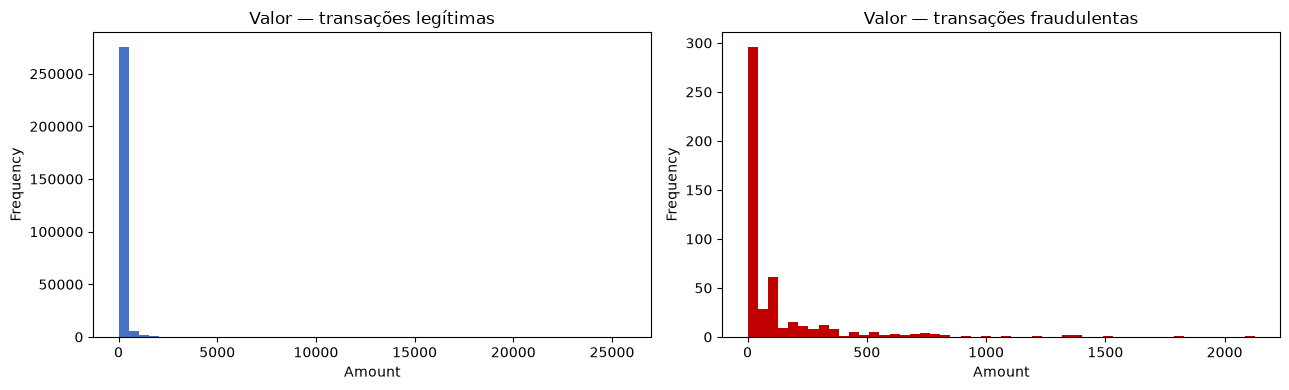

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df[df.Class == 0]["Amount"].plot.hist(bins=50, ax=axes[0], color="#4472c4")
axes[0].set_title("Valor — transações legítimas"); axes[0].set_xlabel("Amount")
df[df.Class == 1]["Amount"].plot.hist(bins=50, ax=axes[1], color="#c00000")
axes[1].set_title("Valor — transações fraudulentas"); axes[1].set_xlabel("Amount")
plt.tight_layout(); plt.show()

## 3. Pré-processamento e split temporal

**Decisão-chave: split temporal, não aleatório.** A base vem ordenada por
`Time`. Fraude é um fenômeno que evolve no tempo (padrões novos surgem,
fraudadores se adaptam). Embaralhar os dados e sortear treino/teste
deixaria o modelo "ver o futuro" durante o treino — um vazamento que
infla as métricas e não se sustenta em produção. Aqui treinamos nos 60%
mais antigos, validamos nos 20% seguintes e testamos nos 20% mais recentes.

**Escalonamento sem leakage:** o `RobustScaler` de `Amount` é ajustado
**apenas no treino** e depois aplicado a validação e teste. Ajustar no
dataset inteiro vazaria estatísticas do teste para o treino.

In [5]:
df = df.sort_values("Time").reset_index(drop=True)

n = len(df)
train_end, val_end = int(n * 0.60), int(n * 0.80)
train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

for name, d in [("Treino", train_df), ("Validação", val_df), ("Teste", test_df)]:
    print(f"{name:>10}: {len(d):>7} linhas | "
          f"fraudes: {int(d['Class'].sum()):>4} ({d['Class'].mean():.4%})")

    Treino:  170884 linhas | fraudes:  360 (0.2107%)
 Validação:   56961 linhas | fraudes:   57 (0.1001%)
     Teste:   56962 linhas | fraudes:   75 (0.1317%)


In [6]:
# Scalers ajustados SÓ no treino
amount_scaler = RobustScaler().fit(train_df[["Amount"]])
time_min, time_max = train_df["Time"].min(), train_df["Time"].max()

def prepara(d):
    d = d.copy()
    d["Amount"] = amount_scaler.transform(d[["Amount"]])
    d["Time"]   = (d["Time"] - time_min) / (time_max - time_min)
    X = d.drop(columns="Class")
    y = d["Class"].astype(int)
    return X, y

X_train, y_train = prepara(train_df)
X_val,   y_val   = prepara(val_df)
X_test,  y_test  = prepara(test_df)
feat_names = X_train.columns.tolist()
print("Pré-processamento concluído.")

Pré-processamento concluído.


## 4. Comparação de modelos

Testamos quatro algoritmos. Onde o algoritmo suporta, usamos
`class_weight="balanced"`, que penaliza mais os erros na classe minoritária
— uma alternativa ao undersampling que **não descarta dados**.

Avaliamos por métricas adequadas a base desbalanceada:

- **Recall (fraude):** das fraudes reais, quantas o modelo pegou. Recall
  baixo = fraudes passando batido.
- **Precision (fraude):** dos alertas de fraude, quantos eram reais.
  Precision baixa = analistas afogados em falsos alarmes.
- **AUC-PR:** resume o trade-off precision/recall em todos os thresholds.
  **É a métrica de referência para dados desbalanceados** — muito mais
  informativa que AUC-ROC neste cenário.

In [7]:
def score_of(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None

def avaliar(nome, y_true, y_pred, y_score):
    return {
        "Modelo": nome,
        "Precision (fraude)": precision_score(y_true, y_pred, zero_division=0),
        "Recall (fraude)": recall_score(y_true, y_pred, zero_division=0),
        "F1 (fraude)": f1_score(y_true, y_pred, zero_division=0),
        "AUC-PR": average_precision_score(y_true, y_score),
        "AUC-ROC": roc_auc_score(y_true, y_score),
    }

In [8]:
modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=6, n_jobs=-1,
        class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
    "SVM Linear": LinearSVC(
        class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
}

resultados = []
for nome, modelo in modelos.items():
    modelo.fit(X_train.values, y_train.values)
    y_pred = modelo.predict(X_val.values)
    y_sc   = score_of(modelo, X_val.values)
    resultados.append(avaliar(nome, y_val, y_pred, y_sc))

tabela = pd.DataFrame(resultados).sort_values("AUC-PR", ascending=False).reset_index(drop=True)
tabela.style.format({c: "{:.3f}" for c in tabela.columns if c != "Modelo"})

,Modelo,Precision (fraude),Recall (fraude),F1 (fraude),AUC-PR,AUC-ROC
0,Regressão Logística,0.027,0.895,0.053,0.773,0.971
1,Random Forest,0.385,0.789,0.517,0.761,0.979
2,SVM Linear,0.032,0.860,0.062,0.600,0.974
3,Gradient Boosting,0.839,0.456,0.591,0.554,0.877


### Leitura dos resultados

Repare no contraste entre **AUC-ROC** (todos ~0,97, praticamente
empatados) e **AUC-PR** (espalhado de ~0,55 a ~0,79). É a demonstração
prática de por que **ROC engana em base desbalanceada**: como há 99,8% de
legítimas, o modelo acerta a classe majoritária com folga e o ROC fica
alto para todo mundo. O AUC-PR, focado na classe rara, é quem realmente
separa os modelos.

Repare também no trade-off entre modelos:
- A **Regressão Logística** captura ~90% das fraudes (recall alto), mas
  com precision baixíssima — gera milhares de falsos positivos.
- O **Random Forest** entrega o melhor equilíbrio (bom AUC-PR com
  precision e recall razoáveis) — é o modelo que seguimos para o ajuste
  de threshold.

Não existe "melhor modelo" no abstrato: existe o melhor modelo **para uma
política de risco**. É o que ajustamos a seguir.

## 5. Ajuste de threshold: o trade-off de negócio

Todo classificador usa, por padrão, o corte de 0,5 na probabilidade. Não
há nada de sagrado nesse número. Movendo o threshold, deslizamos ao longo
da curva precision-recall e escolhemos **onde queremos operar**:

- **Corte mais baixo** → pega mais fraudes (recall ↑), mas com mais falsos
  alarmes (precision ↓). Política de um banco avesso a perdas.
- **Corte mais alto** → menos falsos alarmes (precision ↑), ao custo de
  deixar passar mais fraudes (recall ↓). Política de quem quer poupar a
  equipe de análise.

Escolhemos o threshold **na validação** (nunca no teste) e só então
medimos o desempenho final no teste.

In [9]:
rf = modelos["Random Forest"]
val_scores = rf.predict_proba(X_val.values)[:, 1]

prec, rec, thr = precision_recall_curve(y_val.values, val_scores)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_thr = thr[best_idx]

print(f"Threshold que maximiza F1 (validação): {best_thr:.3f}")
print(f"  precision={prec[best_idx]:.3f}  recall={rec[best_idx]:.3f}  F1={f1s[best_idx]:.3f}")

Threshold que maximiza F1 (validação): 0.680
  precision=0.932  recall=0.719  F1=0.812


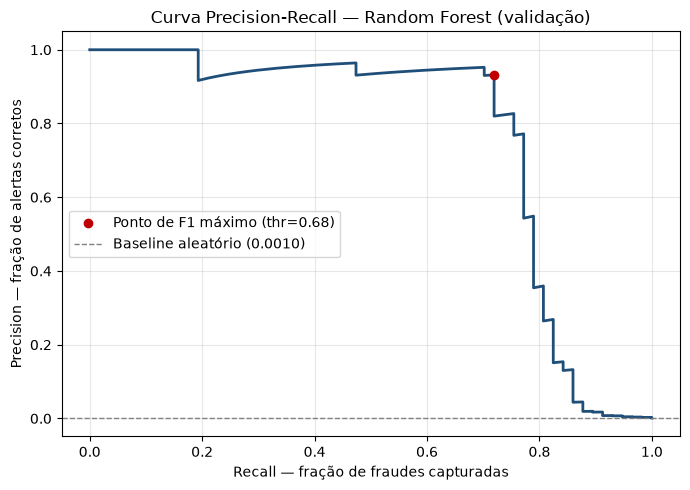

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, lw=2, color="#1f4e79")
plt.scatter(rec[best_idx], prec[best_idx], color="#c00000", zorder=5,
            label=f"Ponto de F1 máximo (thr={best_thr:.2f})")
baseline = y_val.mean()
plt.axhline(baseline, ls="--", color="gray", lw=1,
            label=f"Baseline aleatório ({baseline:.4f})")
plt.xlabel("Recall — fração de fraudes capturadas")
plt.ylabel("Precision — fração de alertas corretos")
plt.title("Curva Precision-Recall — Random Forest (validação)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6. Avaliação final no conjunto de teste

Agora — e só agora — tocamos no conjunto de teste, os 20% de transações
mais recentes, que o modelo nunca viu. Comparamos o corte padrão (0,5) com
o corte ajustado, para tornar o trade-off concreto em número de fraudes
pegas e de clientes incomodados.

In [11]:
def relatorio_teste(thr_usado, titulo):
    scores = rf.predict_proba(X_test.values)[:, 1]
    pred = (scores >= thr_usado).astype(int)
    cm = confusion_matrix(y_test, pred)
    print(f"=== {titulo} (threshold = {thr_usado:.3f}) ===")
    print(f"AUC-PR = {average_precision_score(y_test, scores):.3f}   "
          f"Recall = {recall_score(y_test, pred):.3f}   "
          f"Precision = {precision_score(y_test, pred):.3f}")
    tn, fp, fn, tp = cm.ravel()
    print(f"Fraudes capturadas: {tp} de {tp+fn}   |   "
          f"Falsos alarmes: {fp}   |   Fraudes perdidas: {fn}\n")
    return cm

cm_padrao   = relatorio_teste(0.5, "Corte padrão")
cm_ajustado = relatorio_teste(best_thr, "Corte ajustado (max F1)")

=== Corte padrão (threshold = 0.500) ===
AUC-PR = 0.798   Recall = 0.813   Precision = 0.459
Fraudes capturadas: 61 de 75   |   Falsos alarmes: 72   |   Fraudes perdidas: 14

=== Corte ajustado (max F1) (threshold = 0.680) ===
AUC-PR = 0.798   Recall = 0.720   Precision = 0.885
Fraudes capturadas: 54 de 75   |   Falsos alarmes: 7   |   Fraudes perdidas: 21



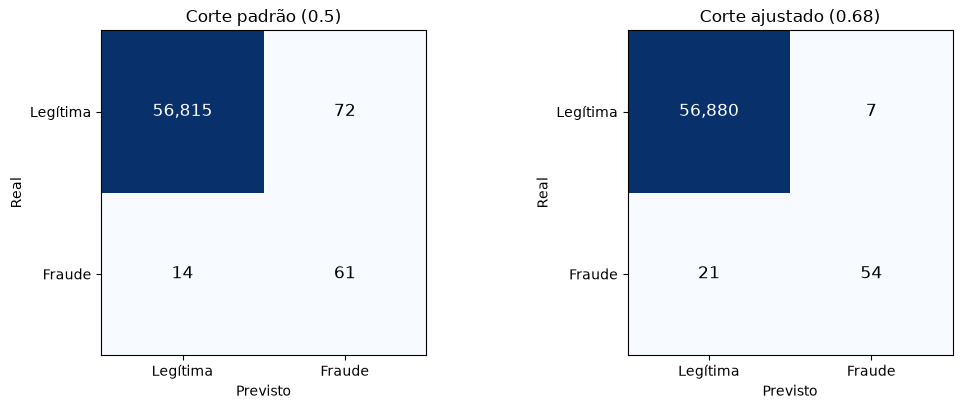

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, cm, titulo in [(axes[0], cm_padrao, "Corte padrão (0.5)"),
                       (axes[1], cm_ajustado, f"Corte ajustado ({best_thr:.2f})")]:
    im = ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=12,
                color="white" if v > cm.max()/2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Legítima", "Fraude"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Legítima", "Fraude"])
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title(titulo)
plt.tight_layout(); plt.show()

O ajuste de threshold não muda o modelo — muda a **política**. O corte
mais alto reduz drasticamente os falsos alarmes, ao custo de perder
algumas fraudes a mais. Qual dos dois é o "certo" depende do custo que o
negócio atribui a cada tipo de erro. O papel do modelo é tornar esse
trade-off explícito e mensurável, para que a decisão seja informada.

## 7. Explicabilidade com SHAP

Em contexto bancário, um modelo de fraude não pode ser uma caixa-preta:
decisões precisam ser auditáveis e justificáveis (inclusive por exigência
regulatória). O **SHAP** decompõe cada previsão, mostrando quanto cada
feature empurrou o score para "fraude" ou "legítima".

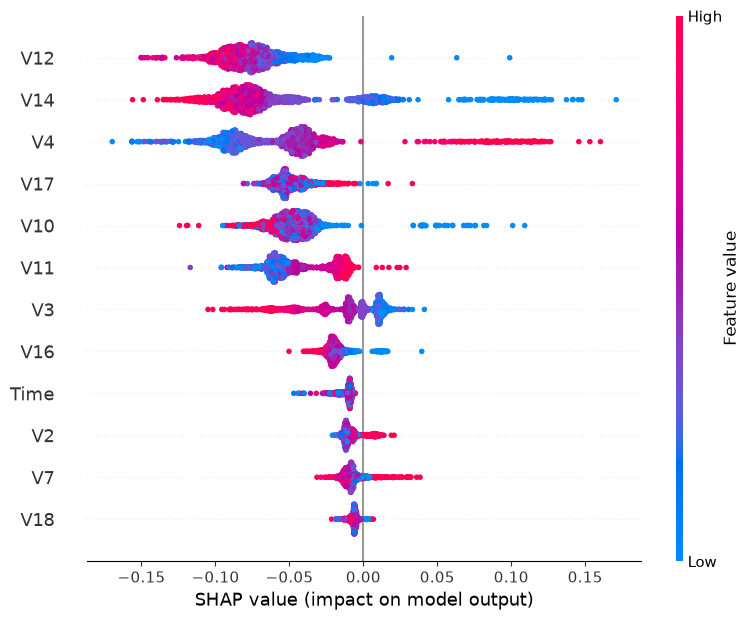

In [13]:
# TreeExplainer é eficiente para modelos de árvore
explainer = shap.TreeExplainer(rf)
X_sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)

# em classificação binária, seleciona as contribuições da classe 'fraude'
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
if sv.ndim == 3:
    sv = sv[:, :, 1]

shap.summary_plot(sv, X_sample, max_display=12, show=True)

Cada ponto é uma transação; a cor é o valor da feature (vermelho = alto,
azul = baixo) e a posição no eixo x é o empurrão para fraude. Algumas das
componentes PCA (`V12`, `V14`, `V4`, `V10`...) concentram a maior parte do
poder discriminante. Como os nomes reais estão anonimizados, não dá para
rotular "o que" cada uma representa — mas em um projeto interno, esse mesmo
gráfico apontaria diretamente para as variáveis de negócio que mais
sinalizam fraude, guiando regras e investigação.

## 8. Conclusão

**O que este projeto mostra:**

- Em detecção de fraude, **a métrica é metade da solução.** Trocar accuracy
  por AUC-PR, recall e matriz de confusão muda completamente qual modelo
  parece "bom" — e evita a armadilha do classificador que acerta 99,8% sem
  pegar fraude nenhuma.
- **Validação honesta importa.** Split temporal e escalonamento ajustado só
  no treino evitam o vazamento que infla resultados de laboratório e
  decepciona em produção.
- **O threshold é uma alavanca de negócio.** O mesmo modelo serve a
  políticas de risco diferentes; explicitar esse trade-off é o que
  transforma um classificador em uma ferramenta de decisão.
- **Explicabilidade não é opcional** em serviços financeiros. O SHAP conecta
  a previsão às variáveis, tornando o modelo auditável.

**Próximos passos:** testar SMOTE como alternativa de balanceamento;
servir o modelo campeão como uma API (FastAPI) que recebe uma transação e
retorna score + faixa de risco + top fatores SHAP; monitorar *drift* com
PSI ao longo do tempo.